In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [26]:
data = pd.read_csv(r"D:\Universty\AI\Project\student_exam_data.csv")
print("Dataset loaded successfully")
print("Shape:", data.shape)
data.head()

Dataset loaded successfully
Shape: (500, 3)


,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [27]:
print("Last 5 Rows")
display(data.tail())

print("\nDataset Info")
data.info()

print("\nStatistical Summary")
display(data.describe())

Last 5 Rows


,Study Hours,Previous Exam Score,Pass/Fail
495,4.180170,45.494924,0
496,6.252905,95.038815,1
497,1.699612,48.209118,0
498,9.769553,97.014241,1
499,9.875897,66.760346,1



Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB

Statistical Summary


,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


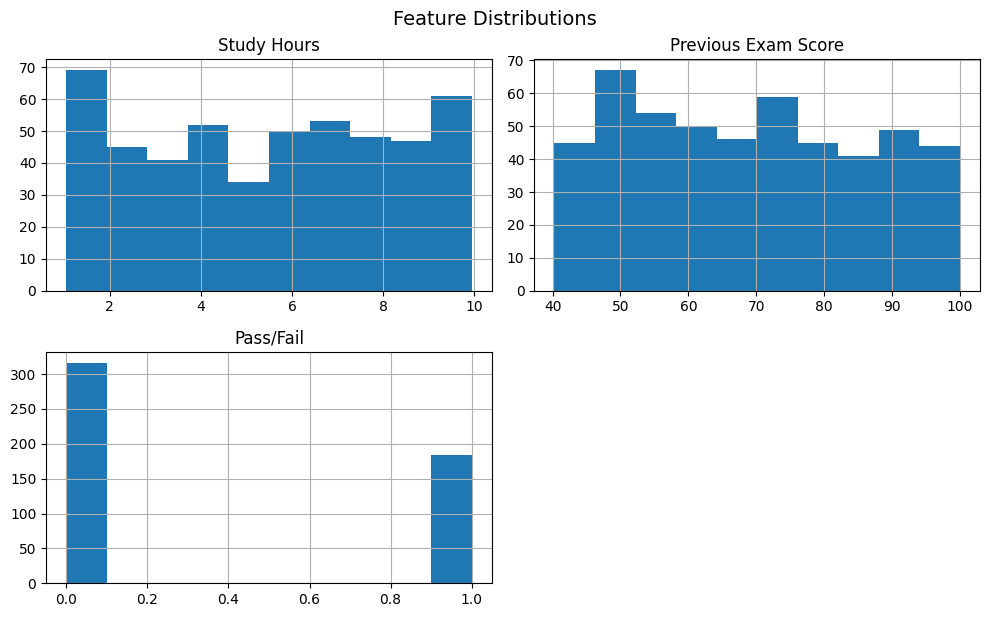

In [28]:
data.hist(figsize=(10, 6))
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.show()

In [29]:
missing = data.isnull().sum()
print("Missing Values per Column:")
print(missing)

if missing.sum() == 0:
    print("\n No missing values found.")
else:
    print(f"\n Total missing values: {missing.sum()}")

Missing Values per Column:
Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64

 No missing values found.


Class Distribution:
Pass/Fail
0    316
1    184
Name: count, dtype: int64

Imbalance Ratio: 1.72x


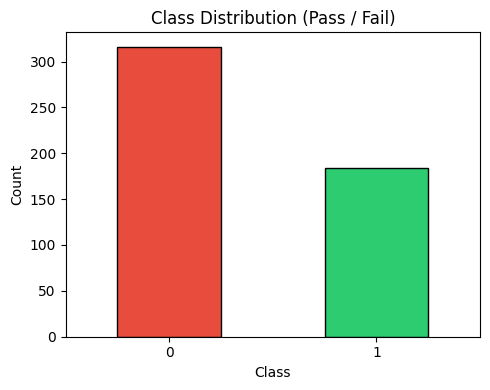

In [30]:
class_counts = data['Pass/Fail'].value_counts()
print("Class Distribution:")
print(class_counts)
print(f"\nImbalance Ratio: {class_counts.max() / class_counts.min():.2f}x")

plt.figure(figsize=(5, 4))
class_counts.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title("Class Distribution (Pass / Fail)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
print(f"Duplicates before: {data.duplicated().sum()}")
data = data.drop_duplicates()
print(f"Duplicates after:  {data.duplicated().sum()}")
print(f"Shape after removing duplicates: {data.shape}")

Duplicates before: 0
Duplicates after:  0
Shape after removing duplicates: (500, 3)


Box Plots BEFORE Outlier Handling


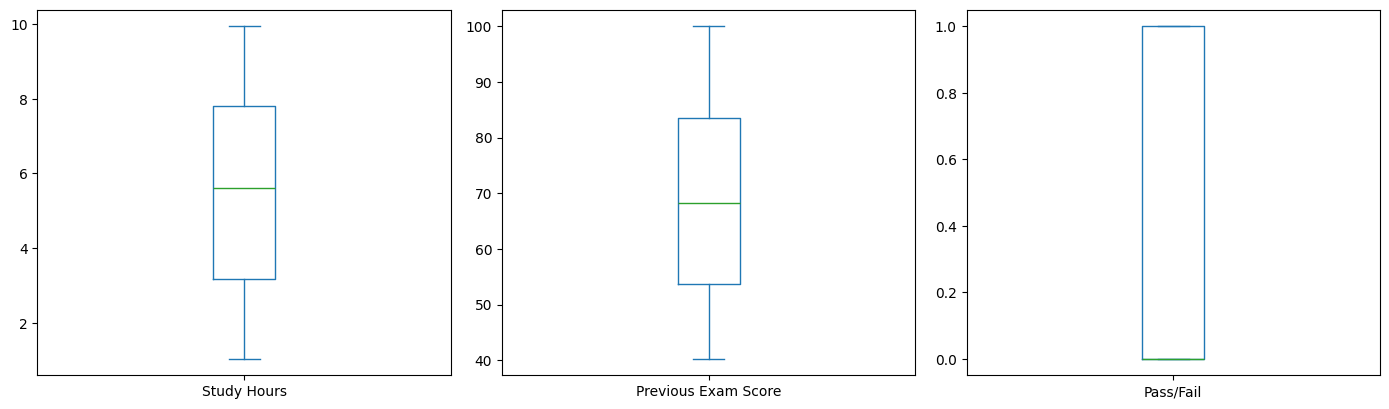


Shape after outlier handling: (500, 3)

Box Plots AFTER Outlier Handling


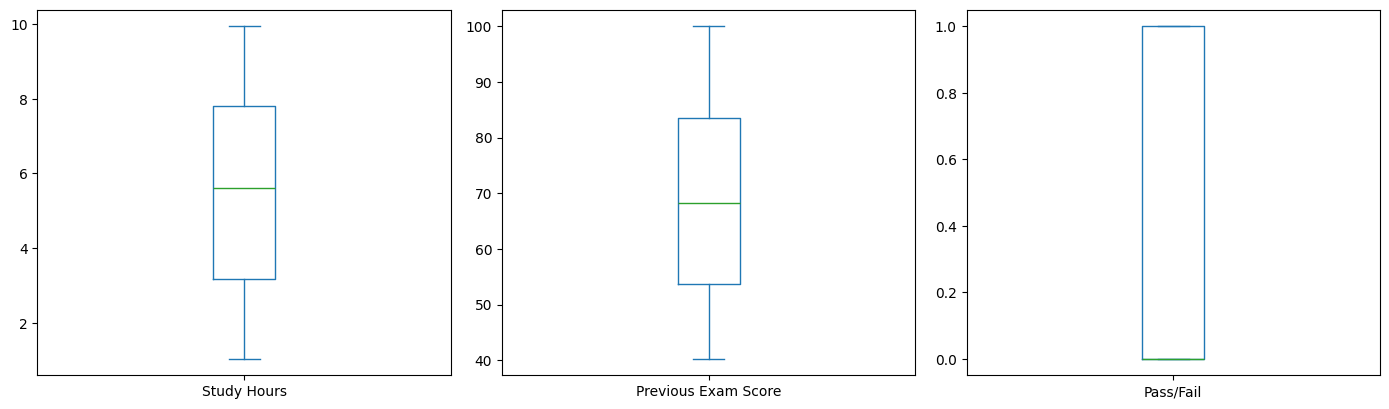

In [32]:
print("Box Plots BEFORE Outlier Handling")
data.plot(kind='box', subplots=True, layout=(2, 3), figsize=(14, 8),
          sharex=False, sharey=False)
plt.tight_layout()
plt.show()

target = "Pass/Fail"

def handle_outliers_median(data, cols):
    data_clean = data.copy()
    for col in cols:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        median = data_clean[col].median()
        data_clean.loc[(data_clean[col] < lower) | (data_clean[col] > upper), col] = median
    return data_clean

numerical_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != target]

data_clean = handle_outliers_median(data, numerical_cols)
print(f"\nShape after outlier handling: {data_clean.shape}")

print("\nBox Plots AFTER Outlier Handling")
data_clean.plot(kind='box', subplots=True, layout=(2, 3), figsize=(14, 8),
                sharex=False, sharey=False)
plt.tight_layout()
plt.show()

In [33]:
data_clean['Efficiency'] = data_clean['Previous Exam Score'] / data_clean['Study Hours']
data_clean.replace([np.inf, -np.inf], 0, inplace=True)
print("✓ Efficiency feature added")
print(data_clean.head())

✓ Efficiency feature added
   Study Hours  Previous Exam Score  Pass/Fail  Efficiency
0     4.370861            81.889703          0   18.735371
1     9.556429            72.165782          1    7.551543
2     7.587945            58.571657          0    7.719040
3     6.387926            88.827701          1   13.905561
4     2.404168            81.083870          0   33.726378


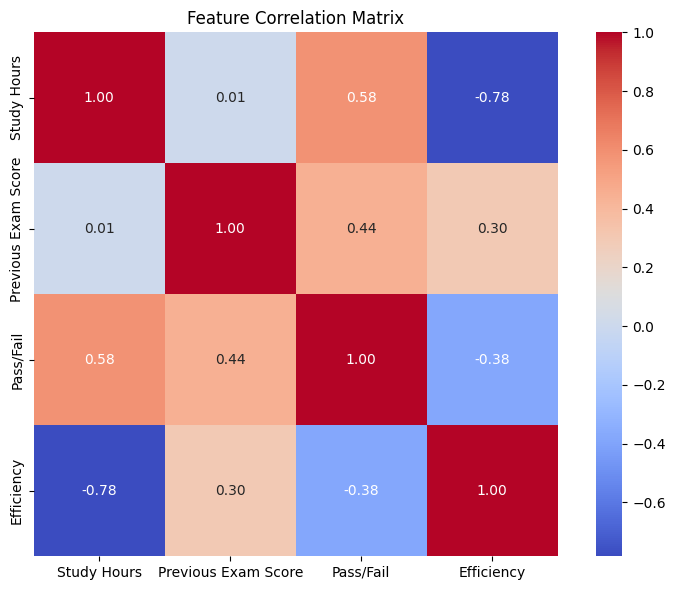


Correlation with target (Pass/Fail):
Study Hours            0.583505
Previous Exam Score    0.443706
Efficiency            -0.381178
Name: Pass/Fail, dtype: float64


In [34]:
numeric_data = data_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelation with target (Pass/Fail):")
print(corr_matrix[target].drop(target).sort_values(ascending=False))

SelectKBest F-Scores (higher = more important):
Study Hours            257.092340
Previous Exam Score    122.077538
Efficiency              84.658273
dtype: float64


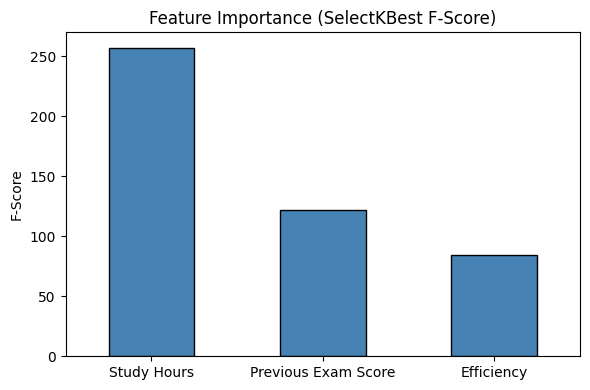

In [35]:
X_fs = data_clean[['Study Hours', 'Previous Exam Score', 'Efficiency']]
le_temp = LabelEncoder()
y_fs = le_temp.fit_transform(data_clean[target])

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_fs, y_fs)
f_scores = pd.Series(selector.scores_, index=X_fs.columns).sort_values(ascending=False)

print("SelectKBest F-Scores (higher = more important):")
print(f_scores)

plt.figure(figsize=(6, 4))
f_scores.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importance (SelectKBest F-Score)")
plt.ylabel("F-Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
X = data_clean.drop(target, axis=1)
y = LabelEncoder().fit_transform(data_clean[target])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print("✓ Preprocessing complete")

Train size: 400 | Test size: 100
✓ Preprocessing complete


=== Logistic Regression – Default Settings ===
Accuracy: 0.8900
              precision    recall  f1-score   support

        Fail       0.92      0.90      0.91        63
        Pass       0.84      0.86      0.85        37

    accuracy                           0.89       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



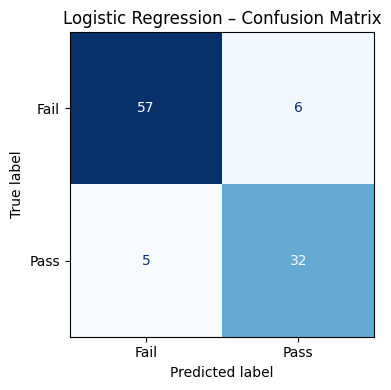

In [37]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_proc, y_train)

y_pred_lr = lr_model.predict(X_test_proc)

print("=== Logistic Regression – Default Settings ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Fail', 'Pass']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=['Fail', 'Pass'], colorbar=False, ax=ax, cmap='Blues')
ax.set_title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.show()

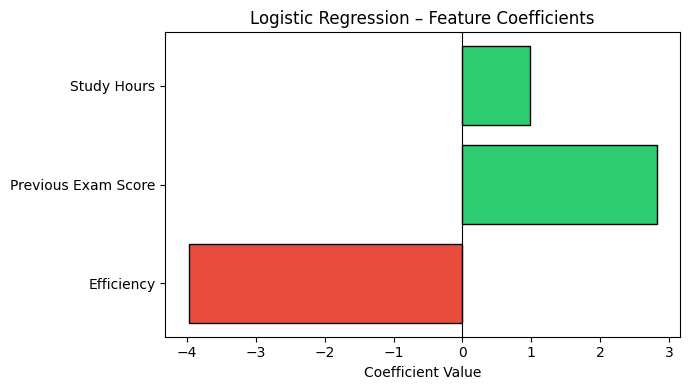

            Feature  Coefficient
         Efficiency    -3.978908
Previous Exam Score     2.821254
        Study Hours     0.980394


In [38]:
feature_names = list(num_cols)
coefs = lr_model.coef_[0][:len(feature_names)]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(7, 4))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Logistic Regression – Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()
print(coef_df.to_string(index=False))

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy: 0.9750

Test Accuracy (After Tuning): 0.9800
              precision    recall  f1-score   support

        Fail       0.98      0.98      0.98        63
        Pass       0.97      0.97      0.97        37

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



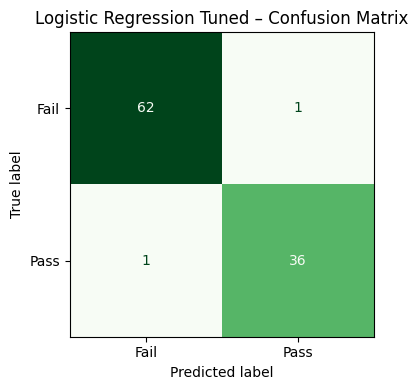

In [39]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_proc, y_train)

print("Best Parameters:", grid_lr.best_params_)
print(f"Best CV Accuracy: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_proc)

print(f"\nTest Accuracy (After Tuning): {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(classification_report(y_test, y_pred_lr_tuned, target_names=['Fail', 'Pass']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_tuned,
    display_labels=['Fail', 'Pass'], colorbar=False, ax=ax, cmap='Greens')
ax.set_title("Logistic Regression Tuned – Confusion Matrix")
plt.tight_layout()
plt.show()

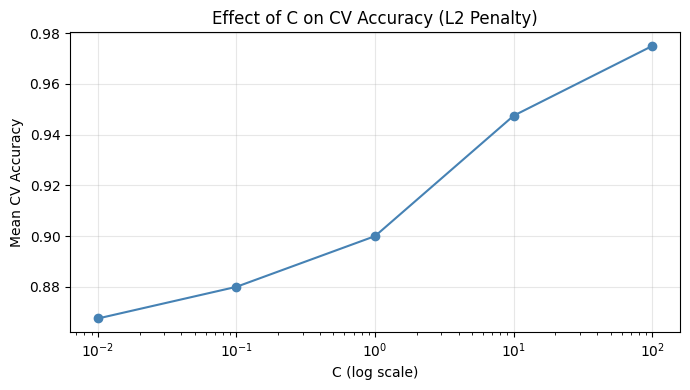

In [40]:
cv_results = pd.DataFrame(grid_lr.cv_results_)
l2_results = cv_results[cv_results['param_penalty'] == 'l2'].copy()
l2_results['param_C'] = l2_results['param_C'].astype(float)
l2_results = l2_results.sort_values('param_C')

plt.figure(figsize=(7, 4))
plt.plot(l2_results['param_C'], l2_results['mean_test_score'], marker='o', color='steelblue')
plt.xscale('log')
plt.title("Effect of C on CV Accuracy (L2 Penalty)")
plt.xlabel("C (log scale)")
plt.ylabel("Mean CV Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Random Forest – Default Settings ===
Accuracy: 1.0000
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        63
        Pass       1.00      1.00      1.00        37

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



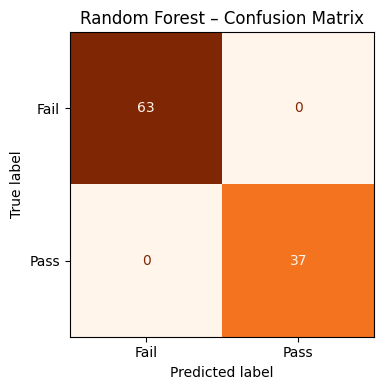

In [41]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_proc, y_train)

y_pred_rf = rf_model.predict(X_test_proc)

print("=== Random Forest – Default Settings ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Fail', 'Pass']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['Fail', 'Pass'], colorbar=False, ax=ax, cmap='Oranges')
ax.set_title("Random Forest – Confusion Matrix")
plt.tight_layout()
plt.show()

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9950

Test Accuracy (After Tuning): 1.0000
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        63
        Pass       1.00      1.00      1.00        37

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



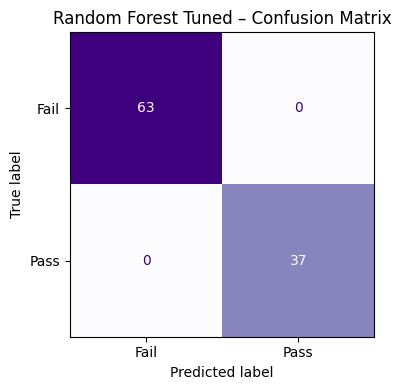

In [42]:
# Hyper-parameter Tuning – Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_proc, y_train)

print("Best Parameters:", grid_rf.best_params_)
print(f"Best CV Accuracy: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_proc)

print(f"\nTest Accuracy (After Tuning): {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Fail', 'Pass']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_tuned,
    display_labels=['Fail', 'Pass'], colorbar=False, ax=ax, cmap='Purples')
ax.set_title("Random Forest Tuned – Confusion Matrix")
plt.tight_layout()
plt.show()

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9950

Test Accuracy (After Tuning): 1.0000
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        63
        Pass       1.00      1.00      1.00        37

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



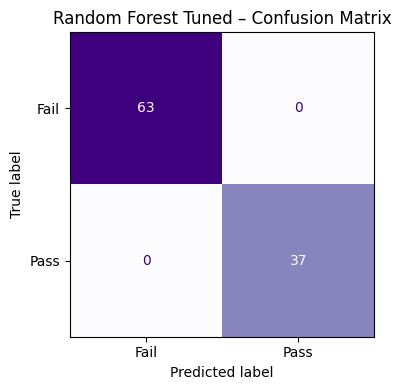

In [43]:
# Hyper-parameter Tuning – Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_proc, y_train)

print("Best Parameters:", grid_rf.best_params_)
print(f"Best CV Accuracy: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_proc)

print(f"\nTest Accuracy (After Tuning): {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Fail', 'Pass']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_tuned,
    display_labels=['Fail', 'Pass'], colorbar=False, ax=ax, cmap='Purples')
ax.set_title("Random Forest Tuned – Confusion Matrix")
plt.tight_layout()
plt.show()

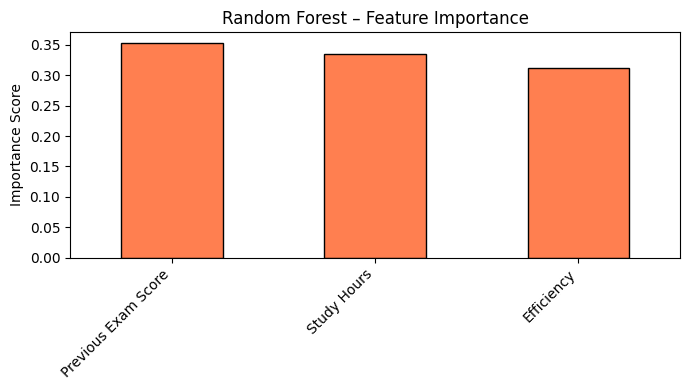

Previous Exam Score    0.352993
Study Hours            0.335399
Efficiency             0.311608
dtype: float64


In [44]:
feat_imp = pd.Series(best_rf.feature_importances_[:len(num_cols)], index=num_cols)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(7, 4))
feat_imp.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Random Forest – Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(feat_imp)

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(best_lr, X_train_proc, y_train, cv=cv, scoring='accuracy')
cv_scores_rf = cross_val_score(best_rf, X_train_proc, y_train, cv=cv, scoring='accuracy')

print("Cross Validation Results (5-Fold)")
print(f"\n Logistic Regression (Tuned):")
print(f"Fold Scores: {np.round(cv_scores_lr, 4)}")
print(f"Mean: {cv_scores_lr.mean():.4f}  |  Std: {cv_scores_lr.std():.4f}")

print(f"\n Random Forest (Tuned):")
print(f"Fold Scores: {np.round(cv_scores_rf, 4)}")
print(f"Mean: {cv_scores_rf.mean():.4f}  |  Std: {cv_scores_rf.std():.4f}")

Cross Validation Results (5-Fold)

 Logistic Regression (Tuned):
Fold Scores: [0.9875 0.9625 0.975  0.95   0.975 ]
Mean: 0.9700  |  Std: 0.0127

 Random Forest (Tuned):
Fold Scores: [1. 1. 1. 1. 1.]
Mean: 1.0000  |  Std: 0.0000


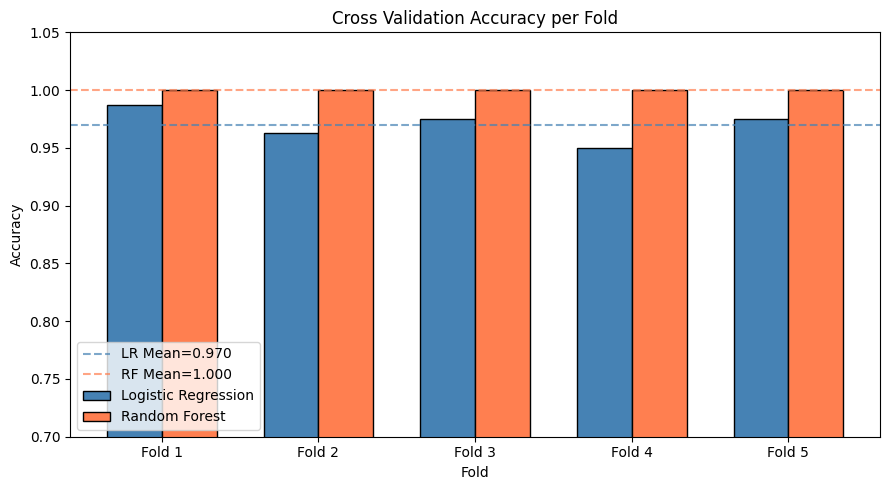

In [46]:
folds = [f"Fold {i+1}" for i in range(5)]
x = np.arange(len(folds))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, cv_scores_lr, width, label='Logistic Regression', color='steelblue', edgecolor='black')
ax.bar(x + width/2, cv_scores_rf, width, label='Random Forest', color='coral', edgecolor='black')

ax.axhline(cv_scores_lr.mean(), color='steelblue', linestyle='--', alpha=0.7,
           label=f'LR Mean={cv_scores_lr.mean():.3f}')
ax.axhline(cv_scores_rf.mean(), color='coral', linestyle='--', alpha=0.7,
           label=f'RF Mean={cv_scores_rf.mean():.3f}')

ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Cross Validation Accuracy per Fold")
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.legend()
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

,Model,Test Accuracy,CV Mean Accuracy,CV Std
0,LR (Default),0.89,NaN,NaN
1,LR (Tuned),0.98,0.97,0.0127
2,RF (Default),1.00,NaN,NaN
3,RF (Tuned),1.00,1.00,0.0000


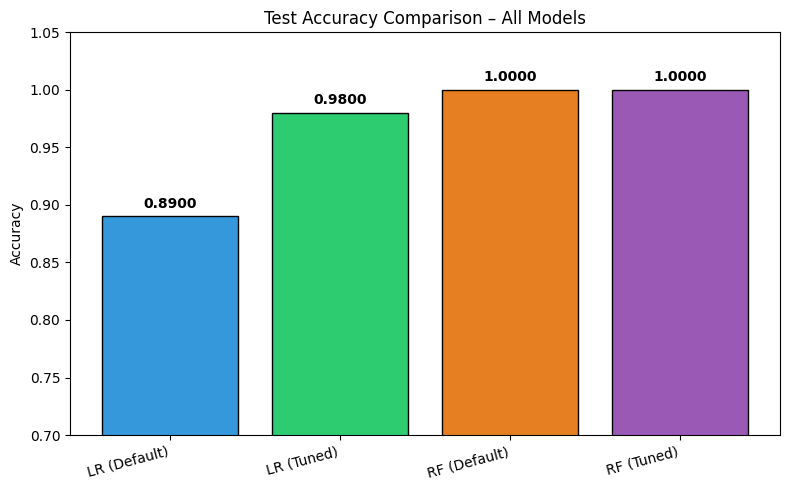

In [47]:
results = {
    'Model': ['LR (Default)', 'LR (Tuned)', 'RF (Default)', 'RF (Tuned)'],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lr_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    'CV Mean Accuracy': [np.nan, cv_scores_lr.mean(), np.nan, cv_scores_rf.mean()],
    'CV Std':           [np.nan, cv_scores_lr.std(),  np.nan, cv_scores_rf.std()]
}

results_df = pd.DataFrame(results)
display(results_df.round(4))

plt.figure(figsize=(8, 5))
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = plt.bar(results_df['Model'], results_df['Test Accuracy'],
               color=colors, edgecolor='black')
plt.ylim(0.7, 1.05)
plt.title("Test Accuracy Comparison – All Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results_df['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [48]:
import joblib
joblib.dump({'preprocessor': preprocessor, 'model': best_rf}, 'student_exam_pass_fail_model.joblib')

['student_exam_pass_fail_model.joblib']